## Imports

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [300]:
# for data prep 
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
# for evaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
#for analysis 
from xgboost import XGBClassifier

In [301]:
#import data 
df = pd.read_csv('Kaggle_churn_training.csv')
testData = pd.read_csv('Kaggle_churn_test.csv')

## EDA



In [302]:
df['Complains'] = df['Complains'].astype('category') 
df['Charge_Amount'] = df['Charge_Amount'].astype('float64') #temp change to float64 so i can fill median
df['Age_Group'] = df['Age_Group'].astype('category')
df['Tariff_Plan'] = df['Tariff_Plan'].astype('category')
df['Status'] = df['Status'].astype('category')
df['Churn'] = df['Churn']. astype('category')

testData['Complains'] = testData['Complains'].astype('category') 
testData['Charge_Amount'] = testData['Charge_Amount'].astype('float64') #temp change to float64 so i can fill median
testData['Age_Group'] = testData['Age_Group'].astype('category')
testData['Tariff_Plan'] = testData['Tariff_Plan'].astype('category')
testData['Status'] = testData['Status'].astype('category')


In [303]:
# Handle missing numerical data
df['Call_Failure'] = df['Call_Failure'].fillna(df['Call_Failure'].mean())
df['Subscription_Length'] = df['Subscription_Length'].fillna(df['Subscription_Length'].mean())
df['Seconds_of_use'] = df['Seconds_of_use'].fillna(df['Seconds_of_use'].mean())
df['Frequency_of_use'] = df['Frequency_of_use'].fillna(df['Frequency_of_use'].mean())
df['Frequency_of_SMS'] = df['Frequency_of_SMS'].fillna(df['Frequency_of_SMS'].mean())
df['Distinct_Called_Numbers'] = df['Distinct_Called_Numbers'].fillna(df['Distinct_Called_Numbers'].mean())
df['Customer_Value'] = df['Customer_Value'].fillna(df['Customer_Value'].mean())

testData['Call_Failure'] = testData['Call_Failure'].fillna(testData['Call_Failure'].mean())
testData['Subscription_Length'] = testData['Subscription_Length'].fillna(testData['Subscription_Length'].mean())
testData['Seconds_of_use'] = testData['Seconds_of_use'].fillna(testData['Seconds_of_use'].mean())
testData['Frequency_of_use'] = testData['Frequency_of_use'].fillna(testData['Frequency_of_use'].mean())
testData['Frequency_of_SMS'] = testData['Frequency_of_SMS'].fillna(testData['Frequency_of_SMS'].mean())
testData['Distinct_Called_Numbers'] = testData['Distinct_Called_Numbers'].fillna(testData['Distinct_Called_Numbers'].mean())
testData['Customer_Value'] = testData['Customer_Value'].fillna(testData['Customer_Value'].mean())

In [304]:
# Handle missing Categorical data
df['Complains'].value_counts(dropna=False)

Complains
 0.0    2314
 1.0     184
NaN       22
Name: count, dtype: int64

In [305]:
df['Complains'] = df['Complains'].fillna(0)
testData['Complains'] = testData['Complains'].fillna(0)

In [306]:
df['Charge_Amount'].value_counts(dropna=False)


Charge_Amount
0.0     1284
1.0      423
2.0      289
NaN      258
3.0      136
4.0       61
5.0       19
8.0       13
7.0       12
9.0       10
6.0        9
10.0       6
Name: count, dtype: int64

In [307]:
# Because this is ordinal data, fill with the median.
df['Charge_Amount'] = df['Charge_Amount'].fillna(df['Charge_Amount'].median())
df['Charge_Amount'] = df['Charge_Amount'].astype('category') # change back to category

testData['Charge_Amount'] = testData['Charge_Amount'].fillna(testData['Charge_Amount'].median())
testData['Charge_Amount'] = testData['Charge_Amount'].astype('category') # change back to category


In [308]:
df['Age_Group'].value_counts(dropna=False)


Age_Group
 3.0    1107
 2.0     827
 4.0     312
 5.0     145
 1.0     100
NaN       29
Name: count, dtype: int64

In [309]:
#fill with mode

df['Age_Group'] = df['Age_Group'].fillna(3)
testData['Age_Group'] = testData['Age_Group'].fillna(3)


In [310]:
#fill with mode
df['Tariff_Plan'] = df['Tariff_Plan'].fillna(1)
testData['Tariff_Plan'] = testData['Tariff_Plan'].fillna(1)

In [311]:
#fill with mode
df['Status'] = df['Status'].fillna(1)
testData['Status'] = testData['Status'].fillna(1)

# All values are already encoded. 

In [312]:
# Feature engineering
# Create engineered features safely
df['use_per_month'] = df['Seconds_of_use'] / df['Subscription_Length'].replace(0, 1)
df['calls_per_month'] = df['Frequency_of_use'] / df['Subscription_Length'].replace(0, 1)
df['sms_per_month'] = df['Frequency_of_SMS'] / df['Subscription_Length'].replace(0, 1)
df['avg_call_length'] = df['Seconds_of_use'] / df['Frequency_of_use'].replace(0, 1)
df['value_per_month'] = df['Customer_Value'] / df['Subscription_Length'].replace(0, 1)
df['failure_per_call'] = df['Call_Failure'] / df['Frequency_of_use'].replace(0, 1)
df['failure_per_month'] = df['Call_Failure'] / df['Subscription_Length'].replace(0, 1)
df['distinct_per_month'] = df['Distinct_Called_Numbers'] / df['Subscription_Length'].replace(0, 1)

# Do the same for testData
testData['use_per_month'] = testData['Seconds_of_use'] / testData['Subscription_Length'].replace(0, 1)
testData['calls_per_month'] = testData['Frequency_of_use'] / testData['Subscription_Length'].replace(0, 1)
testData['sms_per_month'] = testData['Frequency_of_SMS'] / testData['Subscription_Length'].replace(0, 1)
testData['avg_call_length'] = testData['Seconds_of_use'] / testData['Frequency_of_use'].replace(0, 1)
testData['value_per_month'] = testData['Customer_Value'] / testData['Subscription_Length'].replace(0, 1)
testData['failure_per_call'] = testData['Call_Failure'] / testData['Frequency_of_use'].replace(0, 1)
testData['failure_per_month'] = testData['Call_Failure'] / testData['Subscription_Length'].replace(0, 1)
testData['distinct_per_month'] = testData['Distinct_Called_Numbers'] / testData['Subscription_Length'].replace(0, 1)

In [313]:
cat_cols = ['Complains', 'Age_Group', 'Status']

for col in cat_cols:
    df[col] = df[col].cat.codes
    testData[col] = testData[col].cat.codes

In [314]:
features_list = x = [
    'Call_Failure',
    'Subscription_Length',
    'Seconds_of_use',
    'Frequency_of_use',
    'Distinct_Called_Numbers',
    'Customer_Value',
    'Complains',
    'Age_Group',
    'Status',
    'calls_per_month',
    'value_per_month',
    'failure_per_month',
    'distinct_per_month'
]
x = df[features_list]
y = df['Churn'].astype(int)
x_train, x_val, y_train, y_val = train_test_split (x,y, test_size = 0.2, stratify = y, random_state=11)
print(x)

      Call_Failure  Subscription_Length  Seconds_of_use  Frequency_of_use  \
0              8.0            38.000000     4531.370075         71.000000   
1              0.0            39.000000      318.000000          5.000000   
2             10.0            38.000000     4198.000000         69.540376   
3              3.0            38.000000     4531.370075         58.000000   
4             11.0            32.533421     3775.000000         82.000000   
...            ...                  ...             ...               ...   
2515          21.0            19.000000     6697.000000        147.000000   
2516          17.0            17.000000     9237.000000        177.000000   
2517          13.0            18.000000     3157.000000         51.000000   
2518           7.0            11.000000     4695.000000         46.000000   
2519           8.0            11.000000     1792.000000         25.000000   

      Distinct_Called_Numbers  Customer_Value  Complains  Age_Group  Status

In [315]:
# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)

In [316]:
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=11,
    eval_metric='logloss'
)

xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(x_val)

Confusion Matrix:
 [[407  18]
 [ 24  55]]


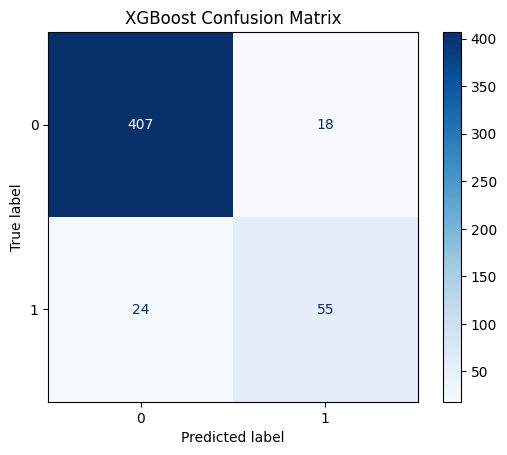

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       425
           1       0.75      0.70      0.72        79

    accuracy                           0.92       504
   macro avg       0.85      0.83      0.84       504
weighted avg       0.91      0.92      0.92       504

Accuracy = 0.9166666666666666
TN = 407
FP = 18
FN = 24
TP = 55
Cost = -2575


In [317]:
cm_xgb = confusion_matrix(y_val, xgb_pred)
print("Confusion Matrix:\n", cm_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

print(classification_report(y_val, xgb_pred))

acc_xgb = accuracy_score(y_val, xgb_pred)
print("Accuracy =", acc_xgb)

tn, fp, fn, tp = cm_xgb.ravel()
cost_xgb = (-50 * fn) + (-25 * tp)

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)
print("Cost =", cost_xgb)

In [318]:
#accuracy with cross-validation
xgb_score = cross_val_score(xgb_model, x_train, y_train,
                             cv = cv, scoring = 'accuracy')
print ('XGBoost CV scores:', xgb_score)
print ('XGBoost mean CV accuracy:', np.mean(xgb_score))

XGBoost CV scores: [0.92574257 0.92555831 0.91811414 0.93796526 0.93796526]
XGBoost mean CV accuracy: 0.929069110384984


In [319]:
x_full = df[features_list]
y_full = df['Churn'].astype(int)

xgb_model.fit(x_full, y_full)

x_test = testData[features_list]
test_pred = xgb_model.predict(x_test)

submission = pd.DataFrame({
    'Customer_ID': testData['Customer_ID'],
    'Churn': test_pred
})

submission.to_csv('xgb_submission.csv', index=False)

## Notes


Run with XGBoost 
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       425
           1       0.75      0.70      0.72        79

    accuracy                           0.92       504
   macro avg       0.85      0.83      0.84       504
weighted avg       0.91      0.92      0.92       504

Accuracy = 0.9166666666666666
TN = 407
FP = 18
FN = 24
TP = 55
Cost = -2575

Cross Validation
XGBoost CV scores: [0.92574257 0.92555831 0.91811414 0.93796526 0.93796526]
XGBoost mean CV accuracy: 0.929069110384984

the score on Kaggle was .94603